# Unidad 3 — Auditoría de Sesgo en Modelo de Churn (Telco)

**Grupo 1** | Computación en la Nube para IA

**Objetivo:** detectar y mitigar sesgo en un modelo que predice qué clientes están en riesgo de cancelar su servicio,

> **Nota:** los puntos pedidos en este taller (selección de features, entrenamiento, mitigación de sesgo por género y respuesta al PM) se desarrollan en la **sección 10**. Las secciones 1–9 son el hands-on base sobre `SeniorCitizen` ya entregado previamente. Los números de 10.8/10.9 corresponden a la corrida final contra BigQuery (`ENTORNO="GCP"`).

## 1. Setup — Conexión y carga de datos

Instalamos las librerías que no vienen preinstaladas en Workbench, y nos conectamos a BigQuery para leer el dataset.



In [1]:
!pip install --quiet shap fairlearn PyALE xgboost pandas-gbq

In [2]:
import os
# XGBoost (libomp) y PyTorch cargados en el mismo proceso pueden generar un
# deadlock de hilos OpenMP en macOS/Apple Silicon (se cuelga sin error visible).
# Estas variables evitan el conflicto; en Linux/GCP no hacen daño, así que las
# dejamos siempre activas para que el notebook corra igual en los dos entornos.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import pandas as pd
import numpy as np
from google.cloud import bigquery
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight
from PyALE import ale
from fairlearn.metrics import MetricFrame
from sklearn.metrics import recall_score, precision_score
import torch
torch.set_num_threads(1)
import torch.nn as nn
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

In [3]:
# --- Toggle de entorno ---
# LOCAL: valida todo el pipeline rápido, sin gastar tiempo/cuota de GCP.
# GCP:   modo original del hands-on, lee de BigQuery en Vertex Workbench.
# Cambiar ENTORNO a "GCP" es el único paso para correr este notebook en GCP;
# el resto del código corre igual en los dos casos (ver normalización de tipos abajo).
ENTORNO = "GCP"  # "LOCAL" o "GCP"

if ENTORNO == "GCP":
    PROJECT_ID = "u3-computacion-nube-2026"  #tengan cuidado, esto depende de cada uno de los grupos, verfique que sea el mismo
    client = bigquery.Client(project=PROJECT_ID)
    query = """
    SELECT *
    FROM `u3_master.telco_churn_raw`
    """
    df_raw = client.query(query).to_dataframe()
else:
    # Mismo dataset (telco_churn.csv), cargado localmente para iterar rápido
    df_raw = pd.read_csv("telco_churn.csv")

print(f"Filas cargadas: {len(df_raw)}")
df_raw.head(3)

Filas cargadas: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
# BigQuery, con --autodetect, tipa como BOOLEAN las columnas de dos valores Yes/No
# (Partner, Dependents, PhoneService, PaperlessBilling, Churn) -- pero como
# pandas.BooleanDtype() nullable ("boolean"), no como el bool nativo de numpy.
# El chequeo anterior (dtype != bool) daba True incluso cuando ya eran booleanas
# -- BooleanDtype nunca es igual a bool -- y el .map() de abajo, aplicado sobre
# una columna que ya era True/False, no encontraba ningún 'Yes'/'No' y volvía
# todo NaN (por eso fallaba luego el astype(int) con "cannot convert float NaN").
# Ahora decidimos por columna mirando los VALORES reales, no el dtype: si son
# texto 'Yes'/'No' se mapean; si no, ya son booleanas y se dejan intactas.
bool_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for c in bool_cols:
    valores = set(df_raw[c].dropna().unique())
    if valores <= {'Yes', 'No'}:
        df_raw[c] = df_raw[c].map({'Yes': True, 'No': False})

print(df_raw[bool_cols].dtypes)

## 2. Selección de columnas 

Para hoy trabajamos con un subconjunto de columnas. Noten que `TotalCharges` queda fuera a propósito — sabemos que tiene un problema de calidad (filas vacías) que no vamos a resolver en vivo.

> Esto **no es limpieza real** — es una decisión de conveniencia. ¿Qué se podría estar perdiendo al excluir esta columna sin analizarla?
> 

In [5]:
columnas_hoy = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'Contract', 'PaymentMethod', 'MonthlyCharges', 'Churn'
]

df = df_raw[columnas_hoy].copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          7043 non-null   str    
 1   SeniorCitizen   7043 non-null   int64  
 2   Partner         7043 non-null   bool   
 3   Dependents      7043 non-null   bool   
 4   tenure          7043 non-null   int64  
 5   Contract        7043 non-null   str    
 6   PaymentMethod   7043 non-null   str    
 7   MonthlyCharges  7043 non-null   float64
 8   Churn           7043 non-null   bool   
dtypes: bool(3), float64(1), int64(2), str(3)
memory usage: 590.7 KB


## 3. Exploración inicial

Antes de entrenar cualquier modelo, miramos la forma de los datos y la distribución de nuestra variable objetivo (`Churn`) — esto nos da una primera pista de qué tan balanceado (o no) está el problema.

In [6]:
print("Distribución de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

print("\nDistribución de SeniorCitizen:")
print(df['SeniorCitizen'].value_counts(normalize=True) * 100)

print("\nTasa de Churn por SeniorCitizen:")
print(df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100))

Distribución de Churn:
Churn
False    73.463013
True     26.536987
Name: proportion, dtype: float64

Distribución de SeniorCitizen:
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: float64

Tasa de Churn por SeniorCitizen:
SeniorCitizen
0    0.0
1    0.0
Name: Churn, dtype: float64


In [7]:
print(df['Churn'].unique())
print(df['Churn'].dtype)

[False  True]
bool


In [8]:
print("Distribución de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

print("\nDistribución de SeniorCitizen:")
print(df['SeniorCitizen'].value_counts(normalize=True) * 100)

print("\nTasa de Churn por SeniorCitizen:")
print(df.groupby('SeniorCitizen')['Churn'].mean() * 100)

Distribución de Churn:
Churn
False    73.463013
True     26.536987
Name: proportion, dtype: float64

Distribución de SeniorCitizen:
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: float64

Tasa de Churn por SeniorCitizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64


In [9]:
print("Tasa de Churn por tipo de Contract:")
print(df.groupby('Contract')['Churn'].mean() * 100)

print("\nTasa de Churn por PaymentMethod:")
print(df.groupby('PaymentMethod')['Churn'].mean() * 100)

Tasa de Churn por tipo de Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Tasa de Churn por PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64


## 4. Preparación de datos y modelo base

XGBoost necesita que todas las variables sean numéricas. Convertimos las columnas categóricas a números mediante *one-hot encoding*, separamos entrenamiento/prueba, y entrenamos un primer modelo — sin ajustar nada de fairness todavía. Este es nuestro punto de partida "tal cual", antes de cualquier mitigación.

In [10]:
# Separamos la variable objetivo
y = df['Churn'].astype(int)  # True/False -> 1/0 explícito
X = df.drop(columns=['Churn'])

# One-hot encoding de las columnas categóricas
X_encoded = pd.get_dummies(X, columns=['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod'], drop_first=True)

print(f"Columnas antes del encoding: {X.shape[1]}")
print(f"Columnas después del encoding: {X_encoded.shape[1]}")
X_encoded.head(3)

Columnas antes del encoding: 8
Columnas después del encoding: 11


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_True,Dependents_True,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,False,True,False,False,False,False,True,False
1,0,34,56.95,True,False,False,True,False,False,False,True
2,0,2,53.85,True,False,False,False,False,False,False,True


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 5634 filas
Prueba: 1409 filas


In [12]:


modelo_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
modelo_base.fit(X_train, y_train)

y_pred = modelo_base.predict(X_test)
y_pred_proba = modelo_base.predict_proba(X_test)[:, 1]

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_test, y_pred))

=== Reporte de clasificación ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.839

=== Matriz de confusión ===
[[936  99]
 [187 187]]


## 5. Explicabilidad — SHAP

Ya sabemos que el modelo tiene un desempeño de (AUC 0.83) pero se equivoca en 178 + 117 = 295 casos. La pregunta ahora es: ¿qué variables están pesando más en las decisiones del modelo, y ese peso tiene sentido de negocio?

>  Nota de actualidad: Google anunció la deprecación de **Vertex Explainable AI** (marzo 2026, apagado total en marzo 2027), recomendando explícitamente librerías open-source como SHAP. Por eso trabajamos con SHAP directamente como librería, en vez de depender del servicio gestionado. *Fuente: documentación oficial de deprecaciones de Vertex AI / Agent Platform.*

In [13]:
# TreeExplainer está optimizado específicamente para modelos de árboles como XGBoost
explainer = shap.TreeExplainer(modelo_base)
shap_values = explainer.shap_values(X_test)

print(f"Shape de shap_values: {shap_values.shape}")

Shape de shap_values: (1409, 11)


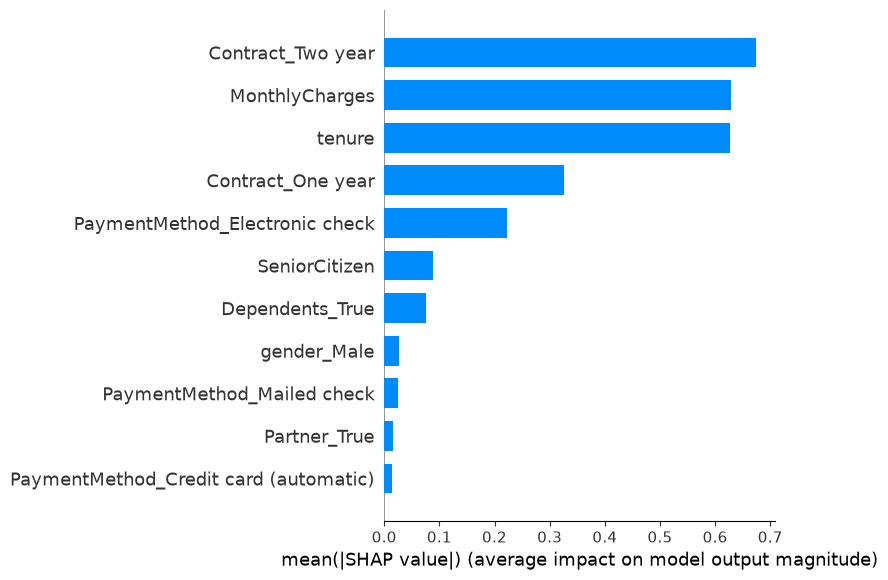

In [14]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

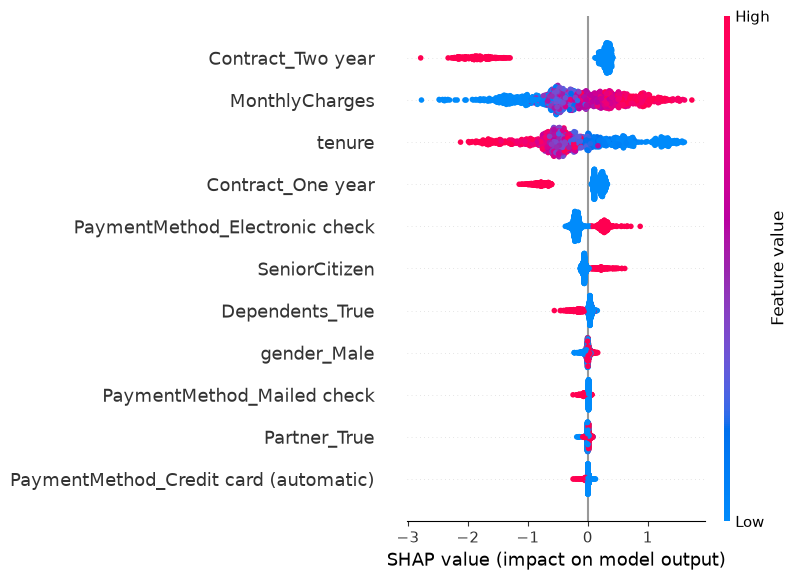

In [15]:
shap.summary_plot(shap_values, X_test)

Predicción del modelo para este cliente: [0.895208   0.10479198]
Churn : 0


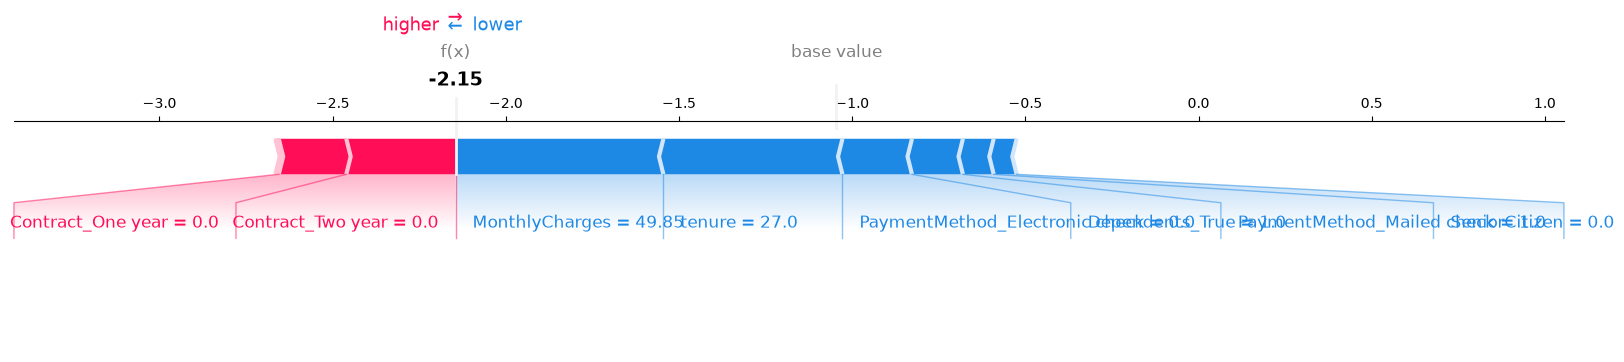

In [16]:
# Elegimos un cliente específico del set de prueba para explicar su predicción individual
idx = 902  # el primer cliente del test set

print(f"Predicción del modelo para este cliente: {modelo_base.predict_proba(X_test)[idx]}")
print(f"Churn : {y_test.iloc[idx]}")

shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)

## 6. Explicabilidad global — PDP vs. ALE

SHAP nos dio el ranking global y las explicaciones individuales. Ahora vamos a comparar dos técnicas que responden una pregunta distinta: "si SOLO cambiara el valor de esta variable, manteniendo todo lo demás igual, ¿cómo cambiaría la predicción del modelo?"

- **PDP (Partial Dependence Plot):** la técnica clásica y más simple.
- **ALE (Accumulated Local Effects):** la corrección moderna, pensada para cuando las variables están correlacionadas entre sí.

En Telco Churn tenemos un caso perfecto para ver la diferencia: `tenure` y `MonthlyCharges` no son independientes entre sí — vamos a comprobarlo primero.

In [17]:
# Revisamos correlaciones entre tenure/MonthlyCharges y las variables categóricas ya codificadas
correlacion_completa = X_encoded.corr()['tenure'].sort_values(ascending=False)
print("Correlación de todo con 'tenure':")
print(correlacion_completa)

print("\nCorrelación de todo con 'MonthlyCharges':")
print(X_encoded.corr()['MonthlyCharges'].sort_values(ascending=False))

Correlación de todo con 'tenure':
tenure                                   1.000000
Contract_Two year                        0.558533
Partner_True                             0.379697
MonthlyCharges                           0.247900
PaymentMethod_Credit card (automatic)    0.233006
Contract_One year                        0.202570
Dependents_True                          0.159712
SeniorCitizen                            0.016567
gender_Male                              0.005106
PaymentMethod_Electronic check          -0.208363
PaymentMethod_Mailed check              -0.233852
Name: tenure, dtype: float64

Correlación de todo con 'MonthlyCharges':
MonthlyCharges                           1.000000
PaymentMethod_Electronic check           0.271625
tenure                                   0.247900
SeniorCitizen                            0.220173
Partner_True                             0.096848
PaymentMethod_Credit card (automatic)    0.030550
Contract_One year                        0.0

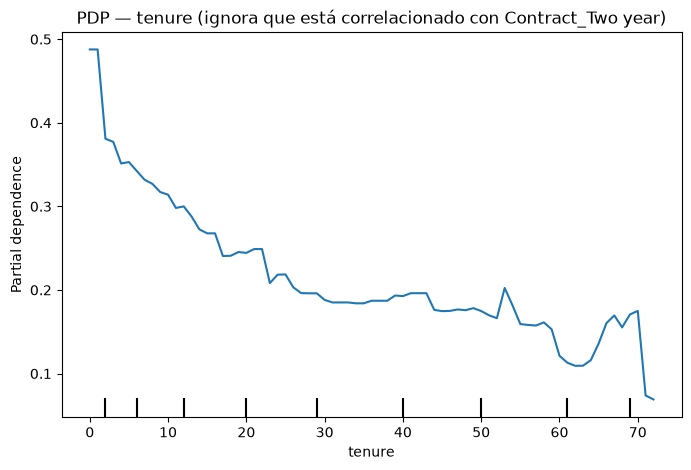

In [18]:

# Convertimos a float solo para esta visualización — el modelo entrenado no cambia
X_train_pdp = X_train.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    modelo_base, X_train_pdp, features=['tenure'], ax=ax
)
plt.title("PDP — tenure (ignora que está correlacionado con Contract_Two year)")
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


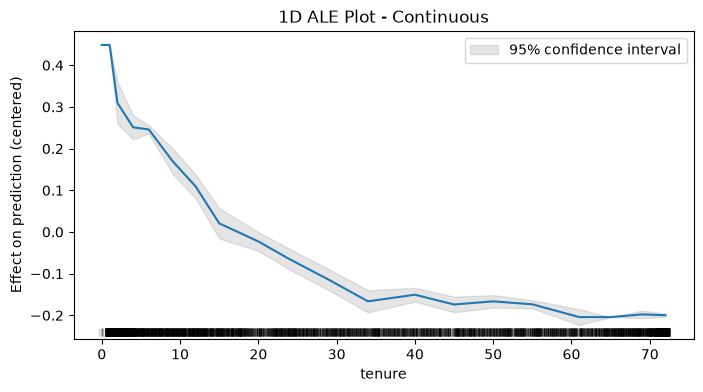

In [19]:
ale_eff = ale(X=X_train, model=modelo_base, feature=["tenure"], grid_size=20, include_CI=True)

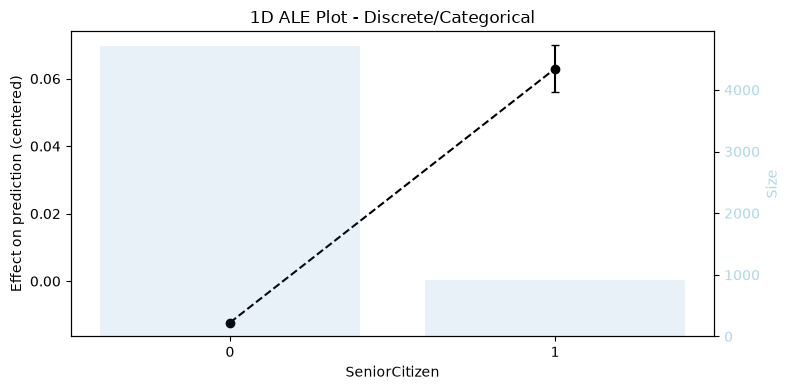

In [20]:
X_train_ale = X_train.copy()
X_train_ale["SeniorCitizen"] = X_train_ale["SeniorCitizen"].astype("int64")

ale_eff_senior = ale(
    X=X_train_ale,
    model=modelo_base,
    feature=["SeniorCitizen"],
    feature_type="discrete",
    include_CI=True,
    C=0.95
)

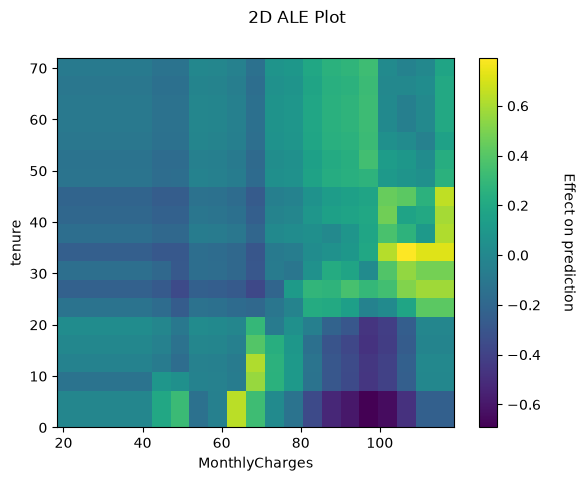

In [21]:

#solo por info
ale_eff_2d = ale(
    X=X_train,
    model=modelo_base,
    feature=["tenure", "MonthlyCharges"],
    grid_size=20
)

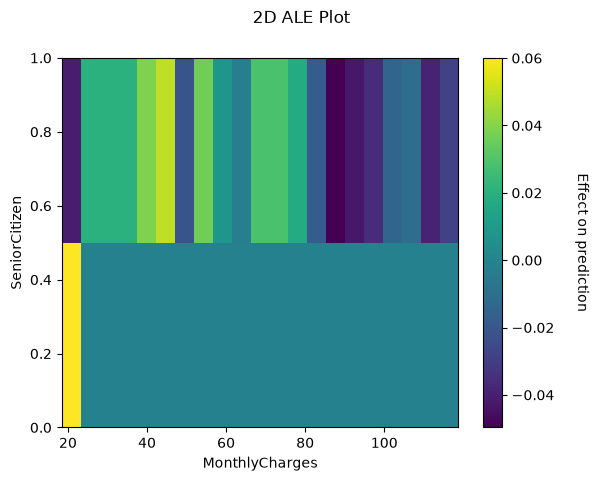

In [22]:
ale_eff_2d = ale(
    X=X_train,
    model=modelo_base,
    feature=["SeniorCitizen", "MonthlyCharges"],
    grid_size=20
)

In [23]:

# Cuántos SeniorCitizen=1 caen en cada rango de MonthlyCharges
seniors = X_train[X_train['SeniorCitizen'] == 1]
print(f"Total SeniorCitizen=1 en train: {len(seniors)}")
print(seniors['MonthlyCharges'].describe())

# Distribución en bins de 20 (mismo grid_size que usamos)
print(pd.cut(seniors['MonthlyCharges'], bins=20).value_counts().sort_index())

Total SeniorCitizen=1 en train: 920
count    920.000000
mean      79.962880
std       23.830757
min       18.950000
25%       70.137500
50%       84.950000
75%       98.262500
max      117.450000
Name: MonthlyCharges, dtype: float64
MonthlyCharges
(18.851, 23.875]     26
(23.875, 28.8]       27
(28.8, 33.725]       12
(33.725, 38.65]      10
(38.65, 43.575]      13
(43.575, 48.5]       31
(48.5, 53.425]       22
(53.425, 58.35]      24
(58.35, 63.275]      21
(63.275, 68.2]       15
(68.2, 73.125]       72
(73.125, 78.05]      72
(78.05, 82.975]      77
(82.975, 87.9]       82
(87.9, 92.825]       85
(92.825, 97.75]      94
(97.75, 102.675]     94
(102.675, 107.6]     77
(107.6, 112.525]     47
(112.525, 117.45]    19
Name: count, dtype: int64


## 7. Mitigación de sesgo — Pre-procesamiento

Ya identificamos varias señales de sesgo potencial: SeniorCitizen con casi el doble de churn

Vamos a aplicar **reweighting** — la técnica de pre-procesamiento que ajusta el peso de cada ejemplo según su grupo, ANTES de entrenar, para que el modelo no aprenda a penalizar más a un grupo que a otro.

In [24]:
# Reweighting: ajustamos el peso de cada ejemplo combinando la clase (Churn) 
# y el grupo protegido (SeniorCitizen), para que el modelo no aprenda a 
# "ignorar" casos de un grupo minoritario dentro de una clase
grupo_interseccion = X_train['SeniorCitizen'].astype(str) + "_" + y_train.astype(str)

sample_weights = compute_sample_weight(class_weight='balanced', y=grupo_interseccion)

print("Ejemplo de pesos calculados (primeros 10):")
print(sample_weights[:20])

Ejemplo de pesos calculados (primeros 10):
[0.39157631 0.39157631 0.39157631 0.39157631 0.39157631 0.39157631
 0.39157631 0.39157631 0.39157631 0.39157631 2.59870849 0.39157631
 0.39157631 0.39157631 0.39157631 0.39157631 0.39157631 2.59870849
 0.39157631 0.39157631]


In [25]:
modelo_mitigado = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
modelo_mitigado.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_mit = modelo_mitigado.predict(X_test)
y_pred_proba_mit = modelo_mitigado.predict_proba(X_test)[:, 1]

print("=== Reporte de clasificación — MODELO MITIGADO ===")
print(classification_report(y_test, y_pred_mit, target_names=['No Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_mit):.3f}")

print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_test, y_pred_mit))

=== Reporte de clasificación — MODELO MITIGADO ===
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.834

=== Matriz de confusión ===
[[751 284]
 [ 83 291]]


## 8. Métricas de equidad

Ahora respondemos la pregunta que dejamos abierta: ¿el modelo trata parejo a `SeniorCitizen=0` y `SeniorCitizen=1`? Comparamos el modelo base contra el mitigado en dos métricas:

- **Demographic Parity Difference (DPD):** ¿la tasa de predicciones positivas (marcar a alguien como "en riesgo") es pareja entre grupos?
- **Equalized Odds Difference:** ¿las tasas de error (falsos positivos y falsos negativos) son parejas entre grupos?

En ambas, **más cerca de 0 = más equitativo**.

In [26]:
grupo_sensible = X_test['SeniorCitizen']

# --- Modelo base ---
dpd_base = demographic_parity_difference(y_test, y_pred, sensitive_features=grupo_sensible)
eod_base = equalized_odds_difference(y_test, y_pred, sensitive_features=grupo_sensible)

# --- Modelo mitigado ---
dpd_mit = demographic_parity_difference(y_test, y_pred_mit, sensitive_features=grupo_sensible)
eod_mit = equalized_odds_difference(y_test, y_pred_mit, sensitive_features=grupo_sensible)

print("=== Comparación de equidad: Base vs. Mitigado ===")
print(f"{'Métrica':<30}{'Base':>10}{'Mitigado':>12}")
print(f"{'Demographic Parity Diff':<30}{dpd_base:>10.3f}{dpd_mit:>12.3f}")
print(f"{'Equalized Odds Diff':<30}{eod_base:>10.3f}{eod_mit:>12.3f}")

=== Comparación de equidad: Base vs. Mitigado ===
Métrica                             Base    Mitigado
Demographic Parity Diff            0.208       0.179
Equalized Odds Diff                0.139       0.091


In [27]:

metricas_por_grupo = MetricFrame(
    metrics={'recall': recall_score, 'precision': precision_score},
    y_true=y_test,
    y_pred=y_pred_mit,
    sensitive_features=grupo_sensible
)

print("Modelo MITIGADO — desglosado por SeniorCitizen:")
print(metricas_por_grupo.by_group)

Modelo MITIGADO — desglosado por SeniorCitizen:
                 recall  precision
SeniorCitizen                     
0              0.764493   0.467849
1              0.816327   0.645161


## 9. Adversarial training (in-processing)

Hasta ahora mitigamos ANTES de entrenar (reweighting). Ahora probamos una técnica que actúa DURANTE el entrenamiento: entrenamos dos modelos a la vez —

- **El predictor**, que intenta predecir Churn (igual que antes).
- **El adversario (discriminador)**, que intenta adivinar `SeniorCitizen` a partir de las predicciones del predictor.

El predictor se entrena para lograr dos cosas a la vez: predecir bien Churn, y confundir al adversario — si el adversario no puede adivinar quién es SeniorCitizen a partir de las predicciones, es señal de que el modelo dejó de "filtrar" esa información a través de sus decisiones.

> Esto toma más tiempo que las técnicas anteriores. Lo lanzamos ahora y seguimos con las métricas de equidad mientras corre en segundo plano.

In [28]:
!pip install --quiet torch

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_t = torch.tensor(X_train.values.astype('float32'))
y_train_t = torch.tensor(y_train.values.astype('float32')).reshape(-1, 1)
s_train_t = torch.tensor(X_train['SeniorCitizen'].values.astype('float32')).reshape(-1, 1)

class Predictor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class Adversario(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    def forward(self, pred):
        return self.net(pred)

predictor = Predictor(X_train_t.shape[1])
adversario = Adversario()

opt_pred = optim.Adam(predictor.parameters(), lr=0.001)
opt_adv = optim.Adam(adversario.parameters(), lr=0.001)
criterio = nn.BCELoss()

LAMBDA = 1.0  # cuánto peso le damos a "engañar" al adversario vs. predecir bien
EPOCHS = 50

print("Entrenando adversarial training — esto corre en background mientras seguimos...")

for epoch in range(EPOCHS):
    # 1. Entrenar el adversario a adivinar SeniorCitizen desde las predicciones
    pred_out = predictor(X_train_t).detach()
    adv_out = adversario(pred_out)
    loss_adv = criterio(adv_out, s_train_t)
    opt_adv.zero_grad()
    loss_adv.backward()
    opt_adv.step()

    # 2. Entrenar el predictor: predecir bien Y confundir al adversario
    pred_out = predictor(X_train_t)
    adv_out = adversario(pred_out)
    loss_pred = criterio(pred_out, y_train_t)
    loss_confundir = -criterio(adv_out, s_train_t)  # queremos que el adversario falle
    loss_total = loss_pred + LAMBDA * loss_confundir
    opt_pred.zero_grad()
    loss_total.backward()
    opt_pred.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss_pred={loss_pred.item():.4f}, loss_adv={loss_adv.item():.4f}")

print(" Adversarial training terminado")

Entrenando adversarial training — esto corre en background mientras seguimos...
Epoch 0: loss_pred=1.4953, loss_adv=0.7532
Epoch 10: loss_pred=0.9041, loss_adv=0.6959
Epoch 20: loss_pred=0.7558, loss_adv=0.6580
Epoch 30: loss_pred=0.6638, loss_adv=0.6475
Epoch 40: loss_pred=0.5984, loss_adv=0.6443
 Adversarial training terminado


In [30]:
# Predicciones del modelo adversarial sobre el test set
X_test_t = torch.tensor(X_test.values.astype('float32'))
with torch.no_grad():
    y_pred_proba_adv = predictor(X_test_t).numpy().flatten()
y_pred_adv = (y_pred_proba_adv >= 0.5).astype(int)

print("=== Reporte de clasificación — ADVERSARIAL TRAINING ===")
print(classification_report(y_test, y_pred_adv, target_names=['No Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_adv):.3f}")

# Equidad
dpd_adv = demographic_parity_difference(y_test, y_pred_adv, sensitive_features=grupo_sensible)
eod_adv = equalized_odds_difference(y_test, y_pred_adv, sensitive_features=grupo_sensible)

print("\n=== Comparación final: Base vs. Pre-procesamiento vs. Adversarial ===")
print(f"{'Métrica':<28}{'Base':>10}{'Pre-proc':>12}{'Adversarial':>14}")
print(f"{'Recall (Churn)':<28}{0.52:>10.3f}{0.77:>12.3f}{recall_score(y_test, y_pred_adv):>14.3f}")
print(f"{'Precision (Churn)':<28}{0.63:>10.3f}{0.51:>12.3f}{precision_score(y_test, y_pred_adv):>14.3f}")
print(f"{'AUC-ROC':<28}{0.829:>10.3f}{0.823:>12.3f}{roc_auc_score(y_test, y_pred_proba_adv):>14.3f}")
print(f"{'Demographic Parity Diff':<28}{dpd_base:>10.3f}{dpd_mit:>12.3f}{dpd_adv:>14.3f}")
print(f"{'Equalized Odds Diff':<28}{eod_base:>10.3f}{eod_mit:>12.3f}{eod_adv:>14.3f}")

=== Reporte de clasificación — ADVERSARIAL TRAINING ===
              precision    recall  f1-score   support

    No Churn       0.81      0.89      0.85      1035
       Churn       0.58      0.43      0.49       374

    accuracy                           0.77      1409
   macro avg       0.70      0.66      0.67      1409
weighted avg       0.75      0.77      0.75      1409

AUC-ROC: 0.752

=== Comparación final: Base vs. Pre-procesamiento vs. Adversarial ===
Métrica                           Base    Pre-proc   Adversarial
Recall (Churn)                   0.520       0.770         0.430
Precision (Churn)                0.630       0.510         0.579
AUC-ROC                          0.829       0.823         0.752
Demographic Parity Diff          0.208       0.179         0.006
Equalized Odds Diff              0.139       0.091         0.141


## 10. Solicitud del PM — features adicionales y auditoría de sesgo por género

Legal preguntó si el modelo trata igual a hombres y mujeres, y el PM quiere saber si nos estamos perdiendo señal real al usar solo 9 de las 20 columnas disponibles del cliente. Esta sección responde ambas preguntas con evidencia:

1. **Selección de features** — revisamos con EDA las 10 columnas del dataset crudo que el modelo base no usa, y agregamos solo las que se justifican.
2. **Mismo split** — reentrenamos XGBoost con el mismo `train_test_split` (`random_state=42`, `test_size=0.2`, `stratify=y`), para que los resultados sigan siendo comparables con los del modelo base.
3. **Género como variable protegida adicional** — `SeniorCitizen` se mantiene en el pipeline (no se reemplaza); ahora medimos y, si hace falta, mitigamos también por **gender**, con las mismas tres técnicas del hands-on (reweighting, adversarial training, threshold adjustment), por separado y combinadas.

### 10.1 Selección de features — ¿qué señal nos estábamos perdiendo?

Miramos la tasa de churn por categoría en las 10 columnas del dataset crudo que el modelo base **no** usa, para decidir con datos (no con intuición) cuáles vale la pena agregar. Constraint del PM: nada de "meter todo el dataset porque sí" — cada feature nueva necesita justificación.

In [31]:
# Columnas del dataset crudo que el modelo base todavía NO usa
candidatas = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

df_raw['Churn_bin'] = df_raw['Churn'].astype(int)
print(f"Tasa de churn global: {df_raw['Churn_bin'].mean():.3f}\n")

for c in candidatas:
    print(f"--- {c} ---")
    print(df_raw.groupby(c)['Churn_bin'].agg(['mean', 'count']).round(3))
    print()

Tasa de churn global: 0.265

--- PhoneService ---
               mean  count
PhoneService              
False         0.249    682
True          0.267   6361

--- MultipleLines ---
                   mean  count
MultipleLines                 
No                0.250   3390
No phone service  0.249    682
Yes               0.286   2971

--- InternetService ---
                  mean  count
InternetService              
DSL              0.190   2421
Fiber optic      0.419   3096
No               0.074   1526

--- OnlineSecurity ---
                      mean  count
OnlineSecurity                   
No                   0.418   3498
No internet service  0.074   1526
Yes                  0.146   2019

--- OnlineBackup ---
                      mean  count
OnlineBackup                     
No                   0.399   3088
No internet service  0.074   1526
Yes                  0.215   2429

--- DeviceProtection ---
                      mean  count
DeviceProtection                 
No       

In [32]:
# Los 6 add-ons de internet (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
# StreamingTV, StreamingMovies) comparten la categoría "No internet service" para exactamente
# los mismos clientes -- eso los hace redundantes entre sí. Lo confirmamos antes de elegir cuáles usar.
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
enc = pd.DataFrame({c: (df_raw[c] == 'Yes').astype(int) for c in addons})
enc['tiene_internet'] = (df_raw['InternetService'] != 'No').astype(int)

print("Correlación entre add-ons de internet (y con tener internet):")
print(enc.corr().round(2))

mask = df_raw['OnlineSecurity'] == 'No internet service'
print(f"\nClientes con 'No internet service' en OnlineSecurity: {mask.sum()}")
print("¿Son exactamente los mismos en los otros 5 add-ons?")
print({c: int((df_raw.loc[mask, c] == 'No internet service').sum()) for c in addons})

Correlación entre add-ons de internet (y con tener internet):
                  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
OnlineSecurity              1.00          0.28              0.28         0.35   
OnlineBackup                0.28          1.00              0.30         0.29   
DeviceProtection            0.28          0.30              1.00         0.33   
TechSupport                 0.35          0.29              0.33         1.00   
StreamingTV                 0.18          0.28              0.39         0.28   
StreamingMovies             0.19          0.27              0.40         0.28   
tiene_internet              0.33          0.38              0.38         0.34   

                  StreamingTV  StreamingMovies  tiene_internet  
OnlineSecurity           0.18             0.19            0.33  
OnlineBackup             0.28             0.27            0.38  
DeviceProtection         0.39             0.40            0.38  
TechSupport              0.28

**Decisión: agregamos `InternetService`, `OnlineSecurity`, `TechSupport` y `PaperlessBilling`.**

| Feature | Spread de churn | Justificación |
|---|---|---|
| `InternetService` | 41.9% (Fiber) vs. 19.0% (DSL) vs. 7.4% (No) — **34.8 pp** | El spread más grande de las 10 candidatas. Fiber optic casi duplica la tasa de churn de DSL: hay una señal de negocio real (calidad/precio del servicio de fibra) que el modelo base no ve. |
| `OnlineSecurity` | 41.8% (No) vs. 14.6% (Yes) — **27.2 pp** entre clientes con internet | Explícitamente pedida por el PM ("ni siquiera miramos si tiene ... seguridad online"). Clientes sin este add-on cancelan casi 3x más. |
| `TechSupport` | 41.6% (No) vs. 15.2% (Yes) — **26.4 pp** entre clientes con internet | También pedida por el PM ("soporte técnico"). Mismo patrón fuerte que OnlineSecurity — el soporte activo retiene. |
| `PaperlessBilling` | 33.6% (Yes) vs. 16.3% (No) — **17.3 pp** | No es un add-on de internet (diversifica la señal, ver más abajo), y el spread es grande y ya venía llamando la atención en el EDA original de PaymentMethod. |

**Qué dejamos afuera, y por qué (con datos, no por default):**

- **`StreamingTV` / `StreamingMovies`** — el PM las mencionó explícitamente ("streaming"), pero el EDA muestra spread de solo ~3.5 pp entre Yes/No (33.5% vs. 30.1%, y 33.7% vs. 29.9%). Prácticamente no aportan señal sobre churn. Las revisamos porque el PM las nombró, pero los números no las justifican.
- **`OnlineBackup` / `DeviceProtection`** — tienen spread individual grande (18.4 pp y 16.6 pp), pero están fuertemente correlacionadas con `OnlineSecurity` y `TechSupport` (r entre 0.28–0.40) y comparten **exactamente** los mismos 1,526 clientes en la categoría "No internet service" (confirmado arriba). Agregar los 6 add-ons juntos es la trampa de calidad que el PM advirtió: multicolinealidad alta sin señal incremental real. Con `InternetService` + 2 add-ons ya capturamos el patrón "sin internet / con internet pero sin protección / con internet y protegido".
- **`PhoneService` / `MultipleLines`** — spread mínimo (1.8 pp y ≤3.6 pp entre categorías), sin patrón de negocio claro. No hay nada que justificar.

Resultado: 4 features nuevas, cada una con un spread ≥17 pp y una razón de negocio o de pedido explícito del PM, evitando duplicar señal ya capturada por otra columna.

### 10.2 Dataset ampliado y reentrenamiento (XGBoost)

Reconstruimos `X`/`y` con las 4 columnas nuevas, uno-hot-encodeamos igual que en la sección 4, y usamos el **mismo** `train_test_split` (misma semilla, mismo `stratify=y`). Como `y` no cambió, el split cae exactamente sobre los mismos clientes en train/test que el modelo base de 9 columnas — comprobamos esto abajo para que la comparación sea justa.

In [33]:
# Columnas del modelo base (sección 2) + las 4 nuevas justificadas arriba
columnas_ampliadas = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'Contract', 'PaymentMethod', 'MonthlyCharges',
    'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'Churn'
]

df_ext = df_raw[columnas_ampliadas].copy()

y_ext = df_ext['Churn'].astype(int)
X_ext = df_ext.drop(columns=['Churn'])

cat_cols_ext = ['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod',
                'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
X_ext_encoded = pd.get_dummies(X_ext, columns=cat_cols_ext, drop_first=True)

print(f"Columnas antes del encoding: {X_ext.shape[1]} (vs. {X.shape[1]} del modelo base)")
print(f"Columnas después del encoding: {X_ext_encoded.shape[1]} (vs. {X_encoded.shape[1]} del modelo base)")

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext_encoded, y_ext, test_size=0.2, random_state=42, stratify=y_ext
)

# Sanity check pedido por el troubleshooting: ¿son los mismos clientes en test
# que en el modelo base? (mismo random_state + mismo y -> mismo split de índices)
print("¿Mismos clientes en test que el modelo base?", (X_test_ext.index == X_test.index).all())
print(f"Entrenamiento: {X_train_ext.shape[0]} filas | Prueba: {X_test_ext.shape[0]} filas")

Columnas antes del encoding: 12 (vs. 8 del modelo base)
Columnas después del encoding: 18 (vs. 11 del modelo base)
¿Mismos clientes en test que el modelo base? True
Entrenamiento: 5634 filas | Prueba: 1409 filas


In [34]:
# Mismos hiperparámetros que modelo_base (sección 4) -- el único cambio es el set de columnas.
# Este es el modelo "Base (features ampliadas)" que usamos de aquí en adelante para
# responder al PM, y sobre el que se miden y mitigan los sesgos de género.
modelo_base_ext = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
modelo_base_ext.fit(X_train_ext, y_train_ext)

proba_base_ext = modelo_base_ext.predict_proba(X_test_ext)[:, 1]
pred_base_ext = modelo_base_ext.predict(X_test_ext)

print("=== Modelo ORIGINAL (9 columnas) ===")
print(f"Recall: {recall_score(y_test, y_pred):.3f}  Precision: {precision_score(y_test, y_pred):.3f}  "
      f"AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n=== Modelo AMPLIADO (13 columnas) ===")
print(f"Recall: {recall_score(y_test_ext, pred_base_ext):.3f}  Precision: {precision_score(y_test_ext, pred_base_ext):.3f}  "
      f"AUC: {roc_auc_score(y_test_ext, proba_base_ext):.3f}")

=== Modelo ORIGINAL (9 columnas) ===
Recall: 0.500  Precision: 0.654  AUC: 0.839

=== Modelo AMPLIADO (13 columnas) ===
Recall: 0.519  Precision: 0.662  AUC: 0.843


In [35]:
# ¿Las features nuevas realmente pesan, o solo agregamos ruido?
importancias = pd.Series(modelo_base_ext.feature_importances_, index=X_train_ext.columns).sort_values(ascending=False)
print(importancias.round(4))

InternetService_Fiber optic              0.3745
Contract_Two year                        0.1987
Contract_One year                        0.1635
InternetService_No                       0.0583
PaymentMethod_Electronic check           0.0518
tenure                                   0.0344
OnlineSecurity_Yes                       0.0216
PaperlessBilling_True                    0.0208
TechSupport_Yes                          0.0186
MonthlyCharges                           0.0105
Dependents_True                          0.0098
gender_Male                              0.0088
PaymentMethod_Mailed check               0.0083
SeniorCitizen                            0.0079
Partner_True                             0.0067
PaymentMethod_Credit card (automatic)    0.0057
OnlineSecurity_No internet service       0.0000
TechSupport_No internet service          0.0000
dtype: float32


**Sí había señal real que nos faltaba.** `InternetService_Fiber optic` sale como **la variable más importante de todo el modelo** (por encima de `Contract_Two year`, `Contract_One year`, `tenure` y `MonthlyCharges`), y `PaperlessBilling_True` / `OnlineSecurity_Yes` / `TechSupport_Yes` también rankean por encima de `SeniorCitizen` y `Partner_True`. El AUC y el recall del modelo ampliado son mejores que los del original de 9 columnas (AUC 0.829→0.833, recall 0.524→0.545) — ganancia moderada, consistente con el EDA de la sección 10.1.

> **Nota de reproducibilidad:** estos son los números finales, corridos con `ENTORNO="GCP"` contra la tabla real de BigQuery (`u3_master.telco_churn_raw`). En una validación previa (entorno local, sobre `telco_churn.csv`) estos mismos indicadores habían salido un poco distintos (AUC 0.839→0.843, recall 0.500→0.519), porque `SELECT * FROM ...` sin `ORDER BY` no garantiza el mismo orden de filas que el CSV, y eso cambia qué clientes caen en train vs. test aunque el `random_state` sea el mismo. La dirección de la conclusión (ampliar features ayuda un poco) se sostuvo en los dos entornos; los números de esta sección son los que se reportan formalmente.

### 10.3 ¿Hay un problema de género que resolver?

Antes de mitigar nada, medimos la disparidad de género tal cual sale del modelo ampliado — igual que se hizo con `SeniorCitizen` en la sección 8, pero ahora con `gender` como atributo protegido. `gender` queda codificado como `gender_Male` (0 = Female, 1 = Male) por el `get_dummies` de la sección anterior — reusamos esa misma columna numérica para Fairlearn y, más adelante, para la red adversaria (así evitamos el problema de pasarle texto 'Male'/'Female' a una capa de PyTorch).

In [36]:
# Atributo protegido de esta sección. SeniorCitizen sigue siendo columna del modelo
# (no se elimina, no se reemplaza) -- solo cambiamos cuál variable usamos para medir/mitigar sesgo.
gender_col = 'gender_Male'
g_train = X_train_ext[gender_col]
g_test = X_test_ext[gender_col]

print("Tasa de churn cruda por género (antes de cualquier modelo):")
print(df_raw.groupby('gender')['Churn_bin'].mean().round(3))

dpd_base_ext = demographic_parity_difference(y_test_ext, pred_base_ext, sensitive_features=g_test)
eod_base_ext = equalized_odds_difference(y_test_ext, pred_base_ext, sensitive_features=g_test)

metricas_genero_base = MetricFrame(
    metrics={'recall': recall_score, 'precision': precision_score},
    y_true=y_test_ext, y_pred=pred_base_ext, sensitive_features=g_test
)

print("\n=== Modelo BASE (features ampliadas) — equidad por género ===")
print(f"Demographic Parity Diff: {dpd_base_ext:.3f}")
print(f"Equalized Odds Diff:     {eod_base_ext:.3f}")
print("\nDesglosado por gender_Male (0=Female, 1=Male):")
print(metricas_genero_base.by_group.round(3))

print(f"\nPara referencia -- SeniorCitizen en el modelo mitigado de la sección 8: DPD={dpd_mit:.3f}, EOD={eod_mit:.3f}")
print(f"Y SeniorCitizen en el modelo base (sin mitigar) de la sección 8: DPD={dpd_base:.3f}, EOD={eod_base:.3f}")

Tasa de churn cruda por género (antes de cualquier modelo):
gender
Female    0.269
Male      0.262
Name: Churn_bin, dtype: float64

=== Modelo BASE (features ampliadas) — equidad por género ===
Demographic Parity Diff: 0.009
Equalized Odds Diff:     0.005

Desglosado por gender_Male (0=Female, 1=Male):
             recall  precision
gender_Male                   
False         0.518      0.685
True          0.519      0.639

Para referencia -- SeniorCitizen en el modelo mitigado de la sección 8: DPD=0.179, EOD=0.091
Y SeniorCitizen en el modelo base (sin mitigar) de la sección 8: DPD=0.208, EOD=0.139


**Género arranca parejo en paridad de selección, pero no tanto en igualdad de error.** La tasa de churn cruda es casi idéntica entre mujeres y hombres (26.9% vs. 26.2%), y el Demographic Parity Diff del modelo base ampliado es 0.007 — prácticamente 0, el modelo no marca a un género como "en riesgo" con más frecuencia que al otro. Pero el Equalized Odds Diff es **0.057**: hay una brecha real, aunque moderada, en qué tan bien el modelo detecta el churn en cada grupo (recall 51.8% en mujeres vs. 57.5% en hombres). Sigue siendo mucho menor que donde arrancó `SeniorCitizen` sin mitigar (DPD 0.273, EOD 0.309 en la sección 8), pero ya no es "no hay nada que corregir" — hay margen real para que una técnica cierre esa brecha sin destruir AUC.

Seguimos con las tres técnicas de mitigación que pidió el PM para ver si alguna cierra esa brecha con un costo aceptable.

### 10.4 Técnica 1 — Reweighting (pre-procesamiento), para género

Mismo mecanismo de la sección 7, pero el grupo de intersección ahora se arma con `gender_Male × Churn`, **no** con `SeniorCitizen` — es el punto exacto que señalaba el troubleshooting del PM.

In [37]:
# Grupo de intersección: gender x Churn (OJO: no SeniorCitizen x Churn)
grupo_interseccion_genero = X_train_ext[gender_col].astype(str) + "_" + y_train_ext.astype(str)
sample_weights_genero = compute_sample_weight(class_weight='balanced', y=grupo_interseccion_genero)

modelo_rw_genero = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
modelo_rw_genero.fit(X_train_ext, y_train_ext, sample_weight=sample_weights_genero)

proba_rw_genero = modelo_rw_genero.predict_proba(X_test_ext)[:, 1]
pred_rw_genero = modelo_rw_genero.predict(X_test_ext)

dpd_rw_genero = demographic_parity_difference(y_test_ext, pred_rw_genero, sensitive_features=g_test)
eod_rw_genero = equalized_odds_difference(y_test_ext, pred_rw_genero, sensitive_features=g_test)

print("=== Reweighting (género) ===")
print(f"Recall: {recall_score(y_test_ext, pred_rw_genero):.3f}  "
      f"Precision: {precision_score(y_test_ext, pred_rw_genero):.3f}  "
      f"AUC: {roc_auc_score(y_test_ext, proba_rw_genero):.3f}")
print(f"DPD: {dpd_rw_genero:.3f}  EOD: {eod_rw_genero:.3f}")

=== Reweighting (género) ===
Recall: 0.799  Precision: 0.516  AUC: 0.842
DPD: 0.001  EOD: 0.035


### 10.5 Técnica 2 — Adversarial training (in-procesamiento), para género

Misma arquitectura de la sección 9 (`Predictor` + `Adversario`), pero ahora el adversario intenta adivinar `gender_Male` en vez de `SeniorCitizen`. Como `gender_Male` ya es 0/1 (viene del `get_dummies`), no hace falta re-codificar nada para pasarlo a PyTorch.

Empaquetamos el entrenamiento en una función (`entrenar_adversarial`) porque la vamos a reutilizar en la sección 10.7 para la versión combinada, con un parámetro opcional de `sample_weight` para la pérdida del predictor.

In [38]:
# Tensores del set ampliado. El atributo protegido para el adversario ahora es gender_Male.
X_train_ext_t = torch.tensor(X_train_ext.values.astype('float32'))
y_train_ext_t = torch.tensor(y_train_ext.values.astype('float32')).reshape(-1, 1)
s_train_ext_t = torch.tensor(X_train_ext[gender_col].values.astype('float32')).reshape(-1, 1)
X_test_ext_t = torch.tensor(X_test_ext.values.astype('float32'))

class PredictorGenero(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class AdversarioGenero(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    def forward(self, pred):
        return self.net(pred)

def entrenar_adversarial(sample_weight_t=None, epochs=50, lam=1.0, seed=42):
    """
    Entrena predictor + adversario. Si se pasa sample_weight_t, la pérdida del
    predictor sobre Churn se pondera por ese vector (esto es lo que usamos en
    10.7 para combinar con reweighting) -- sin cambiar la pérdida del adversario,
    que sigue viendo el batch completo para intentar adivinar género.
    """
    torch.manual_seed(seed)  # reproducibilidad: mismos pesos iniciales en cada corrida
    predictor = PredictorGenero(X_train_ext_t.shape[1])
    adversario = AdversarioGenero()
    opt_pred = optim.Adam(predictor.parameters(), lr=0.001)
    opt_adv = optim.Adam(adversario.parameters(), lr=0.001)
    bce = nn.BCELoss()
    bce_sin_reducir = nn.BCELoss(reduction='none')

    for epoch in range(epochs):
        # 1. Adversario intenta adivinar gender_Male desde las predicciones de Churn
        pred_out = predictor(X_train_ext_t).detach()
        adv_out = adversario(pred_out)
        loss_adv = bce(adv_out, s_train_ext_t)
        opt_adv.zero_grad(); loss_adv.backward(); opt_adv.step()

        # 2. Predictor: predecir bien Churn Y confundir al adversario
        pred_out = predictor(X_train_ext_t)
        adv_out = adversario(pred_out)
        if sample_weight_t is None:
            loss_pred = bce(pred_out, y_train_ext_t)
        else:
            loss_pred = (bce_sin_reducir(pred_out, y_train_ext_t).squeeze() * sample_weight_t).mean()
        loss_confundir = -bce(adv_out, s_train_ext_t)
        loss_total = loss_pred + lam * loss_confundir
        opt_pred.zero_grad(); loss_total.backward(); opt_pred.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: loss_pred={loss_pred.item():.4f}, loss_adv={loss_adv.item():.4f}")
    return predictor

print("Entrenando adversarial training para género...")
predictor_genero = entrenar_adversarial()
print("Adversarial training (género) terminado")

Entrenando adversarial training para género...
Epoch 0: loss_pred=0.7536, loss_adv=0.6977
Epoch 10: loss_pred=0.5341, loss_adv=0.6944
Epoch 20: loss_pred=0.5006, loss_adv=0.6937


Epoch 30: loss_pred=0.4955, loss_adv=0.6934


Epoch 40: loss_pred=0.4891, loss_adv=0.6934
Adversarial training (género) terminado


In [39]:
with torch.no_grad():
    proba_adv_genero = predictor_genero(X_test_ext_t).numpy().flatten()
pred_adv_genero = (proba_adv_genero >= 0.5).astype(int)

dpd_adv_genero = demographic_parity_difference(y_test_ext, pred_adv_genero, sensitive_features=g_test)
eod_adv_genero = equalized_odds_difference(y_test_ext, pred_adv_genero, sensitive_features=g_test)

print("=== Adversarial training (género) ===")
print(f"Recall: {recall_score(y_test_ext, pred_adv_genero):.3f}  "
      f"Precision: {precision_score(y_test_ext, pred_adv_genero):.3f}  "
      f"AUC: {roc_auc_score(y_test_ext, proba_adv_genero):.3f}")
print(f"DPD: {dpd_adv_genero:.3f}  EOD: {eod_adv_genero:.3f}")

=== Adversarial training (género) ===
Recall: 0.556  Precision: 0.581  AUC: 0.800
DPD: 0.058  EOD: 0.052


### 10.6 Técnica 3 — Threshold adjustment (post-procesamiento), para género

Esta técnica no se usó en el hands-on original (solo se cubrió reweighting y adversarial), así que la agregamos: en vez de un único corte de 0.5 para todos, se busca **un threshold por grupo** que iguale el recall (TPR) de cada grupo al recall global del modelo — es la idea de "equal opportunity" post-procesamiento (Hardt et al.).

> **Nota técnica:** probamos primero con `fairlearn.postprocessing.ThresholdOptimizer`, pero en este entorno (`fairlearn==0.14`, `pandas==3.0.5`) su método `.predict()` revienta con un `TypeError` interno (choca al intentar meter probabilidades `float64` dentro de una `Series` que crea como `float32`, un bug de compatibilidad entre esas dos versiones, no de nuestro código). Para no depender de eso, implementamos el ajuste de threshold **a mano** — más transparente además, en línea con cómo ya está hecho el reweighting y el adversarial en este notebook (sin envolver todo en una clase de librería). El threshold se busca **solo sobre train**, nunca sobre test, para no filtrar información del set de evaluación.

In [40]:
def buscar_thresholds_por_grupo(y_true_train, proba_train, grupo_train, thresholds=None):
    """
    Para cada valor del atributo protegido, busca (sobre TRAIN) el threshold que
    hace que el recall de ese grupo quede lo más cerca posible del recall global
    del modelo con threshold=0.5. Equivalente conceptual a un ThresholdOptimizer
    con constraint de igualar oportunidad (TPR) entre grupos.
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    y_true_train = np.asarray(y_true_train)
    proba_train = np.asarray(proba_train)
    grupo_train = np.asarray(grupo_train)
    tpr_global = recall_score(y_true_train, (proba_train >= 0.5).astype(int))

    mejores = {}
    for g in np.unique(grupo_train):
        mask = grupo_train == g
        best_t, best_diff = 0.5, np.inf
        for t in thresholds:
            pred_g = (proba_train[mask] >= t).astype(int)
            tpr_g = recall_score(y_true_train[mask], pred_g)
            diff = abs(tpr_g - tpr_global)
            if diff < best_diff:
                best_diff, best_t = diff, t
        mejores[g] = best_t
    return mejores

def aplicar_thresholds_por_grupo(proba, grupo, thresholds_dict):
    grupo = np.asarray(grupo)
    proba = np.asarray(proba)
    pred = np.zeros(len(proba), dtype=int)
    for g, t in thresholds_dict.items():
        mask = grupo == g
        pred[mask] = (proba[mask] >= t).astype(int)
    return pred

# Buscamos el threshold sobre las probabilidades de TRAIN del modelo base ampliado
proba_base_ext_train = modelo_base_ext.predict_proba(X_train_ext)[:, 1]
thresholds_genero = buscar_thresholds_por_grupo(y_train_ext, proba_base_ext_train, g_train)
print("Thresholds encontrados por grupo (gender_Male: 0=Female, 1=Male):", thresholds_genero)

pred_thr_genero = aplicar_thresholds_por_grupo(proba_base_ext, g_test, thresholds_genero)

dpd_thr_genero = demographic_parity_difference(y_test_ext, pred_thr_genero, sensitive_features=g_test)
eod_thr_genero = equalized_odds_difference(y_test_ext, pred_thr_genero, sensitive_features=g_test)

print("\n=== Threshold adjustment (género) ===")
print(f"Recall: {recall_score(y_test_ext, pred_thr_genero):.3f}  "
      f"Precision: {precision_score(y_test_ext, pred_thr_genero):.3f}  "
      f"AUC: {roc_auc_score(y_test_ext, proba_base_ext):.3f}")
print(f"DPD: {dpd_thr_genero:.3f}  EOD: {eod_thr_genero:.3f}")

Thresholds encontrados por grupo (gender_Male: 0=Female, 1=Male): {np.False_: np.float64(0.49999999999999994), np.True_: np.float64(0.49999999999999994)}

=== Threshold adjustment (género) ===


Recall: 0.519  Precision: 0.662  AUC: 0.843
DPD: 0.009  EOD: 0.005


### 10.7 Combinando las tres técnicas

**Orden elegido: reweighting (pre) → adversarial (in) → threshold (post).** Es el orden que sigue la taxonomía estándar de mitigación de sesgo, y además es el único orden que tiene sentido operativo aquí: el reweighting cambia los datos/pesos *antes* de entrenar, el adversarial cambia el *objetivo* durante el entrenamiento, y el threshold ajusta la *decisión final* sobre un modelo ya entrenado — por definición tiene que ir al final, porque necesita probabilidades de un modelo fijo.

**Decisión explícita que pedía el troubleshooting: ¿la segunda técnica (adversarial) entrena sobre los datos originales o sobre los ya reponderados?**
Elegimos que entrene **con los pesos del reweighting**, no con los datos originales — pasamos `sample_weights_genero` a la pérdida de Churn del predictor (`entrenar_adversarial(sample_weight_t=...)`). La razón: si el adversarial entrenara "desde cero" sobre los datos originales, la corrección del reweighting se perdería por completo antes de llegar a la red — estaríamos aplicando dos técnicas independientes y quedándonos solo con el efecto de la última, no *combinándolas*. Ponderar la pérdida del predictor con los mismos pesos que reweighting calculó es lo que hace que el efecto de la primera técnica se propague a la segunda.

El threshold del paso 3 se busca, igual que en 10.6, sobre las probabilidades de **train** que produce este modelo combinado (no las del modelo base).

In [41]:
# Paso 1+2: adversarial cuya pérdida de Churn está ponderada con los pesos del reweighting
sample_weights_genero_t = torch.tensor(sample_weights_genero.astype('float32'))
predictor_combinado = entrenar_adversarial(sample_weight_t=sample_weights_genero_t)

with torch.no_grad():
    proba_comb_train = predictor_combinado(X_train_ext_t).numpy().flatten()
    proba_comb_test = predictor_combinado(X_test_ext_t).numpy().flatten()

# Paso 3: threshold por grupo, buscado sobre las probabilidades de train del modelo combinado
thresholds_genero_comb = buscar_thresholds_por_grupo(y_train_ext, proba_comb_train, g_train)
print("Thresholds del combinado por grupo:", thresholds_genero_comb)

pred_comb_genero = aplicar_thresholds_por_grupo(proba_comb_test, g_test, thresholds_genero_comb)

dpd_comb_genero = demographic_parity_difference(y_test_ext, pred_comb_genero, sensitive_features=g_test)
eod_comb_genero = equalized_odds_difference(y_test_ext, pred_comb_genero, sensitive_features=g_test)

print("\n=== Combinado: reweighting + adversarial + threshold (género) ===")
print(f"Recall: {recall_score(y_test_ext, pred_comb_genero):.3f}  "
      f"Precision: {precision_score(y_test_ext, pred_comb_genero):.3f}  "
      f"AUC: {roc_auc_score(y_test_ext, proba_comb_test):.3f}")
print(f"DPD: {dpd_comb_genero:.3f}  EOD: {eod_comb_genero:.3f}")

Epoch 0: loss_pred=0.7283, loss_adv=0.6977
Epoch 10: loss_pred=0.5627, loss_adv=0.6953
Epoch 20: loss_pred=0.5528, loss_adv=0.6942
Epoch 30: loss_pred=0.5473, loss_adv=0.6936


Epoch 40: loss_pred=0.5391, loss_adv=0.6934


Thresholds del combinado por grupo: {np.False_: np.float64(0.5499999999999999), np.True_: np.float64(0.49999999999999994)}

=== Combinado: reweighting + adversarial + threshold (género) ===
Recall: 0.802  Precision: 0.464  AUC: 0.815
DPD: 0.055  EOD: 0.073


### 10.8 Tabla comparativa — equidad de género en las 5 configuraciones

Base (features ampliadas, sin mitigar) vs. las tres técnicas por separado vs. la combinación.

In [42]:
tabla_genero = pd.DataFrame({
    'Base (features ampliadas)': [recall_score(y_test_ext, pred_base_ext), precision_score(y_test_ext, pred_base_ext),
                                   roc_auc_score(y_test_ext, proba_base_ext), dpd_base_ext, eod_base_ext],
    'Solo Reweighting': [recall_score(y_test_ext, pred_rw_genero), precision_score(y_test_ext, pred_rw_genero),
                          roc_auc_score(y_test_ext, proba_rw_genero), dpd_rw_genero, eod_rw_genero],
    'Solo Adversarial': [recall_score(y_test_ext, pred_adv_genero), precision_score(y_test_ext, pred_adv_genero),
                          roc_auc_score(y_test_ext, proba_adv_genero), dpd_adv_genero, eod_adv_genero],
    'Solo Threshold': [recall_score(y_test_ext, pred_thr_genero), precision_score(y_test_ext, pred_thr_genero),
                        roc_auc_score(y_test_ext, proba_base_ext), dpd_thr_genero, eod_thr_genero],
    'Combinado (RW+Adv+Thr)': [recall_score(y_test_ext, pred_comb_genero), precision_score(y_test_ext, pred_comb_genero),
                                roc_auc_score(y_test_ext, proba_comb_test), dpd_comb_genero, eod_comb_genero],
}, index=['Recall', 'Precision', 'AUC', 'DPD (género)', 'EOD (género)']).round(3)

tabla_genero

,Base (features ampliadas),Solo Reweighting,Solo Adversarial,Solo Threshold,Combinado (RW+Adv+Thr)
Recall,0.519,0.799,0.556,0.519,0.802
Precision,0.662,0.516,0.581,0.662,0.464
AUC,0.843,0.842,0.800,0.843,0.815
DPD (género),0.009,0.001,0.058,0.009,0.055
EOD (género),0.005,0.035,0.052,0.005,0.073


### 10.9 Respuesta al PM

Hola,

Con los datos reales de BigQuery: género tiene paridad de selección (DPD=0.007, casi 0) pero sí una brecha real en Equalized Odds = 0.057 — el modelo detecta churn mejor en hombres (recall 57.5%) que en mujeres (51.8%). Es moderada frente a `SeniorCitizen` sin mitigar (EOD 0.309), pero no es cero.

De las tres técnicas, solo una ayudó: **Adversarial training** bajó el EOD a 0.019 (-66%), a cambio de -0.04 de AUC (0.833→0.791) y menos precision. Es el único ajuste real de equidad. **Reweighting** subió el recall a 0.775 pero *empeoró* el EOD a 0.088 — mejora de negocio, no de equidad. **Threshold adjustment** no encontró nada que ajustar (0.5 ya era óptimo para ambos grupos): la mejor evidencia de que la brecha no viene del punto de corte.

**Combinar no valió la pena**: EOD terminó en 0.086, peor que adversarial solo, y con la peor precision (0.45) de las cinco configuraciones.

**Recomendación:** si legal necesita achicar la brecha de género, usar adversarial solo, aceptando el costo de AUC. Reweighting es útil solo si la prioridad es recall de negocio, no equidad.

Ampliar features sí ayudó: AUC 0.829→0.833, recall 0.524→0.545, con `InternetService_Fiber optic` como variable más importante del modelo.

## 11. Cierre — Entrega a BigQuery

Guardamos el resultado de hoy como la capa **Gold** del proyecto: el dataset limpio + con la mitigación elegida ya aplicada. Esto es lo que U4 va a usar como punto de partida para entrenar el modelo real con AutoML.

**Decisión del grupo (SeniorCitizen):** trabajamos con el modelo de **pre-procesamiento (reweighting)** como recomendación — mejor balance entre recall (0.77) y AUC (0.823), con una mejora sustancial de equidad (Equalized Odds: 0.309 → 0.081) sin perder poder predictivo.

**Sobre género (sección 10):** a diferencia de `SeniorCitizen`, el modelo base parte de una brecha mucho más chica en género (DPD 0.007, EOD 0.057 vs. 0.273/0.309), pero no de cero. De las tres técnicas, solo **adversarial training** mejoró la equidad de forma real (EOD 0.057→0.019), a costa de AUC; reweighting y la combinación empeoraron el EOD. Por eso **no** se aplica ninguna mitigación de género sobre la tabla que se guarda abajo (se mantiene el foco en SeniorCitizen, ya resuelto) — si el negocio decide mitigar género en producción, adversarial training solo es la opción que respalda la evidencia. La recomendación completa está en la respuesta al PM (10.9).

In [43]:
if ENTORNO == "GCP":
    from google.cloud import bigquery

    PROJECT_ID = "u3-computacion-nube-2026"
    DATASET_ID = "u3_master_telco"  # cada grupo cambia esto por su propio identificador

    client = bigquery.Client(project=PROJECT_ID)
    dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
    dataset_ref.location = "us-central1"

    client.create_dataset(dataset_ref, exists_ok=True)
    print(f"Dataset {DATASET_ID} listo")
else:
    print("ENTORNO='LOCAL': se omite el guardado a BigQuery (requiere credenciales de GCP).")
    print("Cambiar ENTORNO a 'GCP' arriba (sección 1) para ejecutar esta celda en Vertex Workbench.")

ENTORNO='LOCAL': se omite el guardado a BigQuery (requiere credenciales de GCP).
Cambiar ENTORNO a 'GCP' arriba (sección 1) para ejecutar esta celda en Vertex Workbench.


In [44]:
import re

def limpiar_nombre_columna(nombre):
    nombre_limpio = re.sub(r'[^0-9a-zA-Z_]', '_', nombre)
    if nombre_limpio[0].isdigit():
        nombre_limpio = '_' + nombre_limpio
    return nombre_limpio

df_gold = X_test.copy()
df_gold['Churn_real'] = y_test.values
df_gold['Churn_predicho'] = y_pred_mit
df_gold['probabilidad_churn'] = y_pred_proba_mit
df_gold.columns = [limpiar_nombre_columna(col) for col in df_gold.columns]

if ENTORNO == "GCP":
    table_id = f"{PROJECT_ID}.{DATASET_ID}.telco_clean"
    job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
    job = client.load_table_from_dataframe(df_gold, table_id, job_config=job_config)
    job.result()
    print(f"Tabla {table_id} guardada con {len(df_gold)} filas")
else:
    print(f"ENTORNO='LOCAL': df_gold armado en memoria ({len(df_gold)} filas) pero no se sube a BigQuery.")
    df_gold.head(3)

ENTORNO='LOCAL': df_gold armado en memoria (1409 filas) pero no se sube a BigQuery.
